# 特征探索分析

1. **`cat_12` 特征浮点异常情况**（提取前100项统计浮点值占比）。
2. **数值型特征 `num_*` 原始分布情况**（用于证明进行双重对数平滑的必要性）。

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False

In [34]:
df = pd.read_csv('train.csv', nrows=100000) 
print(f"shape: {df.shape}")
# 统计id列中0和1的占比
print(df['target'].value_counts(normalize=True))

# 查找空值情况
print("\n")
print(df.head(800000).isna().any(axis=None))

shape: (100000, 60)
target
0.0    0.98651
1.0    0.01349
Name: proportion, dtype: float64


False


### 1. `cat_12` 异常浮点情况统计

我们提取前 100 项 `cat_12` 数据，观察其中到底有多少项是真正的“小数/浮点数”，说明强制转为 `int` 截断小数的必要性。

In [35]:
subset = df['cat_12'].head(800000)

print(f"浮点异常比例: {(subset.dropna() % 1 != 0).sum() / len(subset) * 100:.2f}%")

浮点异常比例: 13.57%


### 2. 数值特征 `num_*` 原始分布情况全览

我们对 38 个数值型特征（平滑前）进行直方图绘制。横坐标有自适应截断处理。

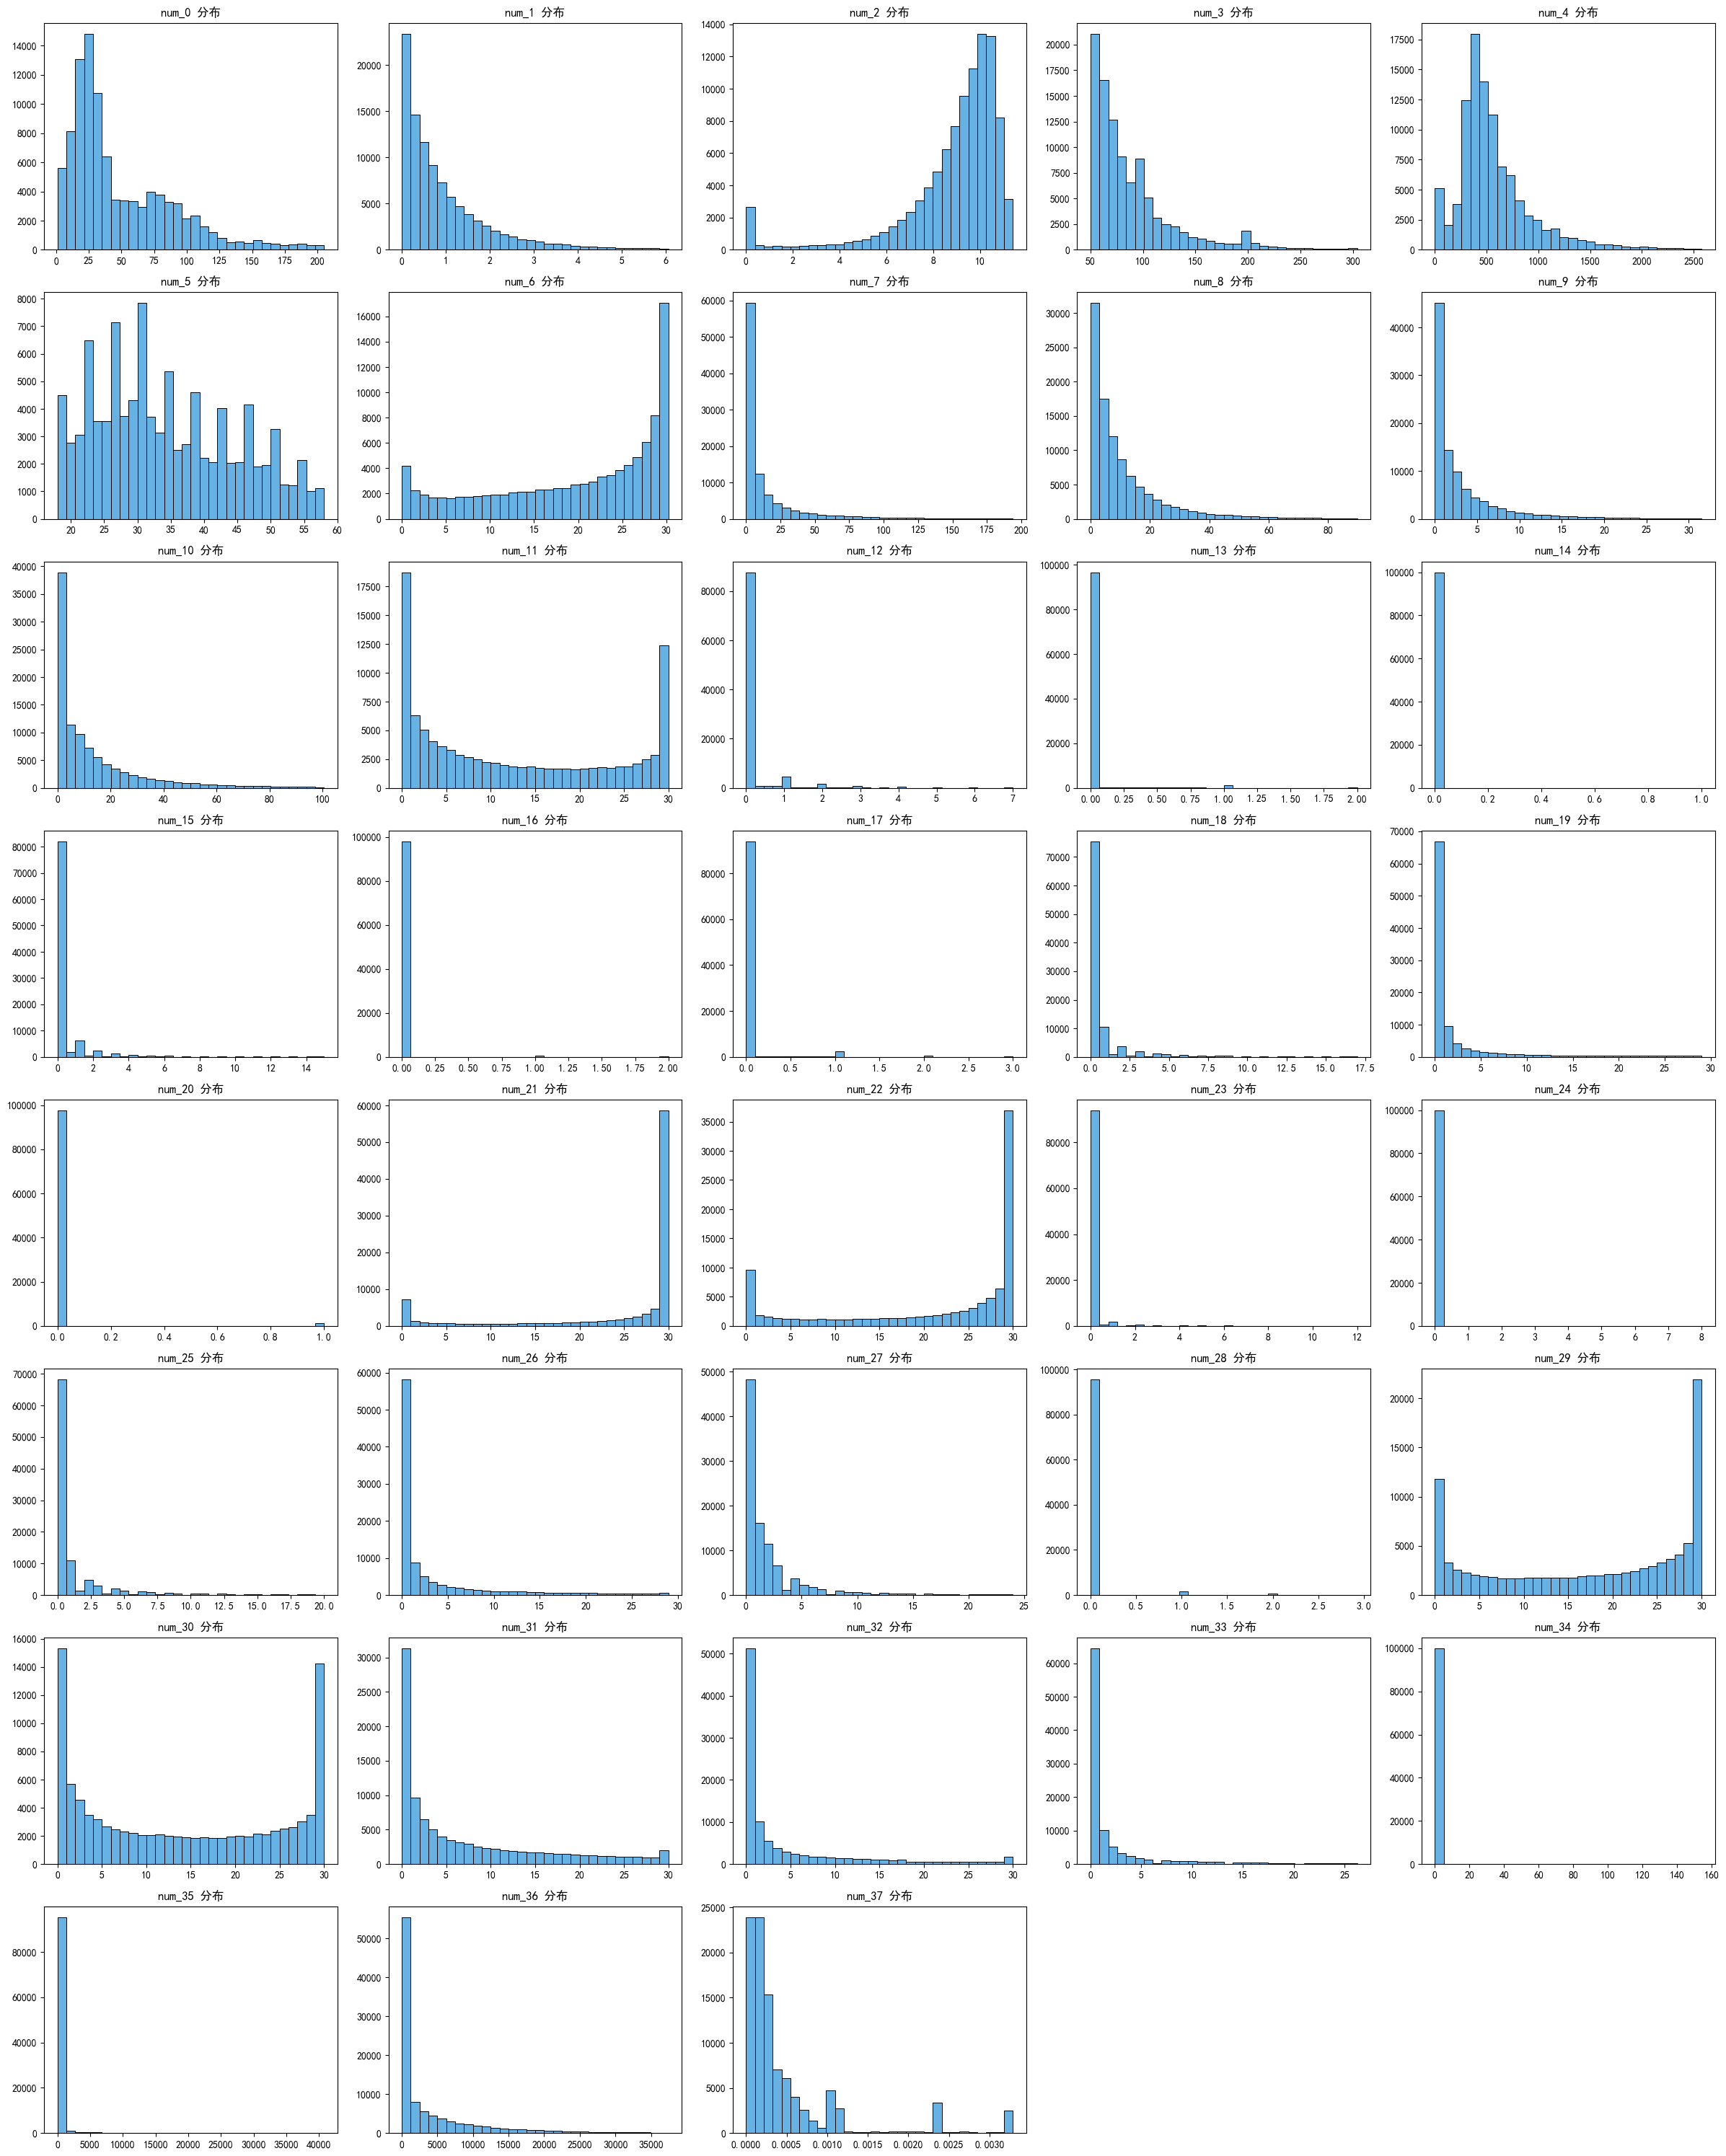

In [36]:
num_cols = [f'num_{i}' for i in range(38)]

# 构建 8*5 画布
fig, axes = plt.subplots(8, 5, figsize=(24, 30))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    if col in df.columns:
        plot_data = df[col].copy()

        q99 = plot_data.quantile(0.99)
        min_val = plot_data.min()
        
        if q99 > min_val:
            plot_data = plot_data[plot_data <= q99]
        else:
            non_baseline_data = plot_data[plot_data > min_val]
            if len(non_baseline_data) > 0:
                q95_nz = non_baseline_data.quantile(0.95)
                plot_data = plot_data[plot_data <= q95_nz]
        
        sns.histplot(plot_data, bins=30, ax=axes[i], kde=False, color='#3498db')
        axes[i].set_title(f"{col} 分布")
        axes[i].set_ylabel('')
        axes[i].set_xlabel('')

# 隐藏多余的子图空白
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()